# Introduction to Machine Learning

In this notebook, we will look at some simple examples of machine learning. Although the examples are not complex, they will capture many of the elements of machine learning that you will find in more complex examples.

The first example takes a set of data composed of pairs of x and y values. The x and y values are related by a simple algebraic rule:
$$
y=Mx
$$
We don't know the value of $M$. Of course, knowing that the relationship is the same for all the pairs of numbers, we could simply take the first pair and divide $y$ by $x$ to find $M$. However, we will take a different approach that will still help us find the value of $M$ but which will generalize to other cases.

In the code cell below, we first create some data pairs $(x, y)$ and choose a value of $M$. The $x$ values are chosen randomly and the $y$ values are calculated using:

$$y=Mx$$

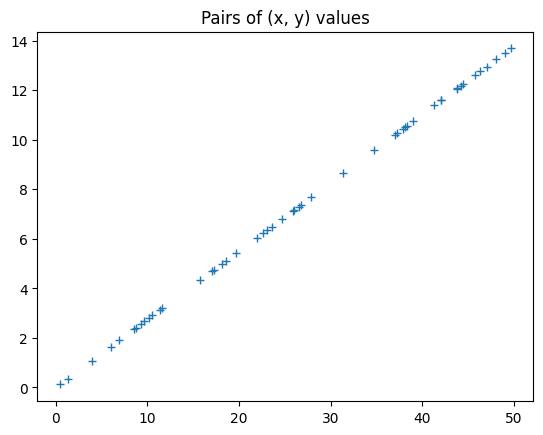

In [9]:
import random, matplotlib.pyplot as plt, matplotlib
import math, numpy as np

# This is the 'hidden' parameter that the model does not know
M = 0.2754

# We generate n points (x, y) that follow the relationship y=Mx
n = 50
max_x = 50
rng = np.random.default_rng()
x_vals = rng.uniform(0, max_x, size = n)
y_vals = M*x_vals

plt.plot(x_vals, y_vals, '+')
plt.title("Pairs of (x, y) values")
plt.show()

## Finding $M$

We take the following approach to finding the value of $M$. For clarity, the upper case $M$ is the true 'unknown' value we are trying to find. We will use a lower case $m$ for our current guess. 
1. First make an  intial guess for $M$ which we call $m$. We will start with $m=0.5$.
2. Examine the pairs of values $(x, y)$ in order, one-by-one, as follows.
3. Using our current guess for $m$ and the value of $x$ we predict the value of $y$.
4. We then work out the error in our prediction: $E = y - mx$.
5. If our error is positive, we have underestimated $y$. So we increase the value of $m$ a little.
6. If our error is negative, we have overestimated $y$. So we decrease the value of $m$ a little.

What we've not explicitly stated above is how much to increase or decrease our value of $m$ based on the error $E$. The key here is to adjust the value of $m$ in proportion to the size of the error, but not by that much. To do this, we introduce one more variable, $L$, called the learning rate, that allows us to fine tune this process. The math is as follows:

### Calculate Error
$$ E = y -mx $$

### Adjust $m$
$$ m = m +L \cdot E $$

The code below does this for each pair of $(x, y)$ values in the dataset. At each step, the current value of $m$ is printed.

In [10]:
#Set initial values
m = 0.4
L = 0.1

for i in range(n):
    print(f"Current guess m = {m:.5f}")
    x = x_vals[i]
    y = y_vals[i]
    E = y - m*x
    m = m + L*E
    
print(f"Final guess m = {m:.5f}")

Current guess m = 0.40000
Current guess m = -0.21072
Current guess m = 1.92064
Current guess m = 0.18426
Current guess m = 0.42784
Current guess m = 0.08353
Current guess m = 0.19864
Current guess m = 0.27294
Current guess m = 0.28254
Current guess m = 0.24985
Current guess m = 0.37683
Current guess m = -0.04246
Current guess m = 0.32016
Current guess m = 0.23224
Current guess m = 0.23414
Current guess m = 0.34095
Current guess m = 0.06483
Current guess m = 0.24802
Current guess m = 0.32064
Current guess m = 0.24957
Current guess m = 0.31350
Current guess m = 0.24265
Current guess m = 0.29926
Current guess m = 0.27709
Current guess m = 0.27421
Current guess m = 0.27731
Current guess m = 0.27002
Current guess m = 0.28691
Current guess m = 0.27357
Current guess m = 0.28239
Current guess m = 0.28149
Current guess m = 0.25480
Current guess m = 0.29995
Current guess m = 0.20692
Current guess m = 0.50968
Current guess m = 0.27065
Current guess m = 0.27394
Current guess m = 0.27731
Current gu

## Visualizing the Learning

The code below is a modification of the example above. It adds in two lists called `m_vals` and `errors`. This allows us to keep track of the values of `m` and `E` at each step of the iteration.
Once the code has run, we can then plot graphs to visualize how the value of `m` and the error values are changing with each iteration. Run the code below to see the graphs.

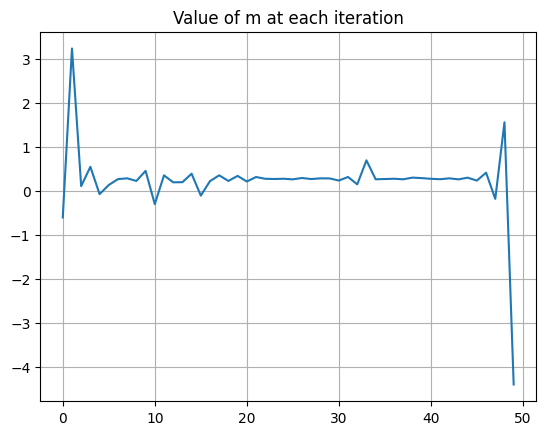

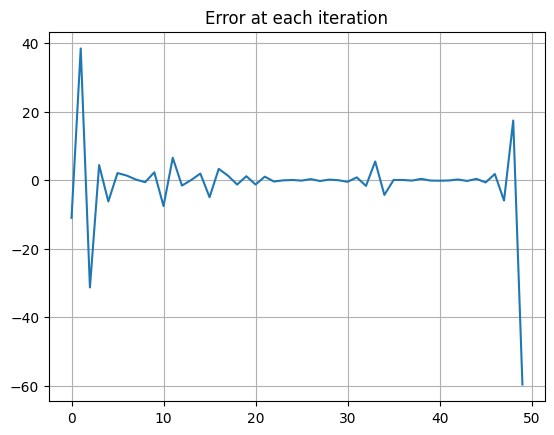

In [11]:
# Reset m and L
M = 0.2754
m = 0.5
L = 0.1

n = len(x_vals)
m_vals = []
errors = []
for i in range(n):
    x = x_vals[i]
    y = y_vals[i]
    e = y - m*x
    m = m + L*e
    errors.append(e)
    m_vals.append(m)

plt.plot(m_vals)
plt.title("Value of m at each iteration")
plt.grid(True)
plt.show()
plt.plot(errors)
plt.grid(True)
plt.title("Error at each iteration")
plt.show()

## Task 1

In this task, you need to investigate how the various elements of the model influence the convergence. You can do this in pairs. Here is a list of all the things you can change:

1. Change the starting value of m, which is set to `m=0.5` above.
2. Change the learning rate, `L`, which is set to `L=0.1` above.
3. Change the data. The x values are generated randomly. If you run the first code cell again, you'll get a new set of random data. You can also change the number of data points `n` which is initially set to `n=20` and the range from which `x` values are generated (set by `max_x` which is initially set to `20`.)
4. Change the value of the true parameter `M` which is set initially to `M=0.62371`.

In each case, try different values and attempt to draw some broad conclusions about how changing these values affect the convergence. Write your observations below.

**Write your observations in the markdown cell below**









## Extension: Repeating with Noise

We have observed that for the simple example above, you only need one data point to work out $M$.

Now we will repeat this experiment, but we will add noise to the data, so that relationship $y=Mx$ only holds on average, not for every single $(x, y)$ pair.

In this example, our iterative approach may prove to be more useful as a single data point is unlikely to give us a precise estimate of $M$.

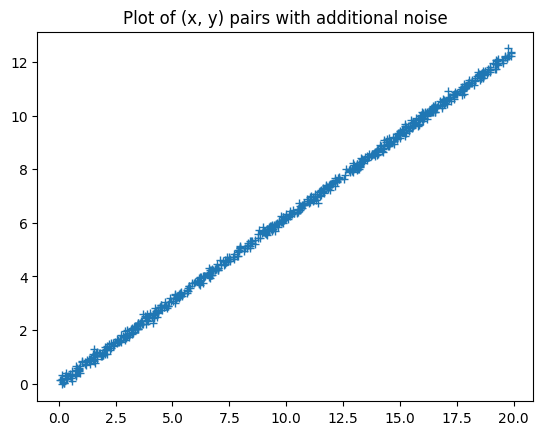

In [23]:
# This is the 'hidden' parameter that the model does not know
M = 0.621371

# We generate some points (x, y) that follow the relationship y=Mx, on average, but with additional noise in each single (x, y) pair
n = 700
max_x = 20

rng = np.random.default_rng()
x_vals = rng.uniform(0, max_x, size = n)

# We use a normal distribution to add some noise to the y values.
# The y_noise variable sets the variance for the normal distribution - increasing this will cause the data to be more spread out.
y_noise = 0.1
y_vals = M*x_vals + rng.normal(0, y_noise, size=n)

# The plot should show that the values are now spread out and not on a single line.
plt.plot(x_vals, y_vals, '+')
plt.title("Plot of (x, y) pairs with additional noise")
plt.show()

## Creating a Training Function

To streamline our code, we will create a function called `train()`. We can then call this function to carry out the iterations for a given dataset, starting guess and learning rate.

In [24]:
# The function train() takes the following arguments:
# m = initial guess for m
# L = learning rate
# x_vals, y_vals = numpy arrays for x and y values

def train(m, L, x_vals, y_vals):
    errors = []
    m_vals = []
 
    for i in range(len(x_vals)):
        x = x_vals[i]
        y = y_vals[i]
        e = y - m*x
        m = m+L*e
        errors.append(e)
        m_vals.append(m)
    return m, m_vals, errors

In [28]:
# Now we call our train() function with initial values and training data
m, m_vals, errors = train(1, 0.001, x_vals, y_vals)
print(f"Final value of m = {m:.5f}")

Final value of m = 0.62076


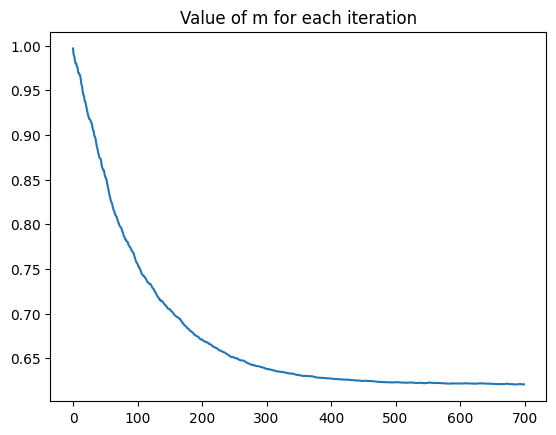

In [29]:
# Plot the m values to visualize convergence
plt.plot(m_vals)
plt.title("Value of m for each iteration")
plt.show()

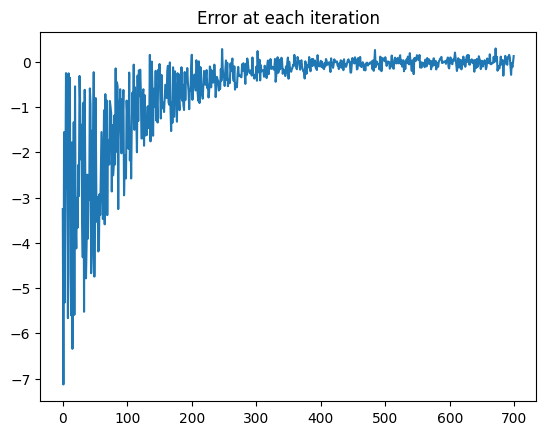

In [30]:
# Plot the errors to visualize convergence
plt.plot(errors)
plt.title("Error at each iteration")
plt.show()

## Task 2

As before, you should try to explore how the various elements of the data and model affect convergence. Before running the code, you might want to think about

1. Change the starting value of m, which is set to `m=0.5` above.
2. Change the learning rate, `L`, which is set to `L=0.1` above.
3. Change the data. The x values are generated randomly. If you run the first code cell again, you'll get a new set of random data. You can also change the number of data points `n` which is initially set to `n=50` and the range from which `x` values are generated (set by `max_x` which is initially set to `20`.)
4. Change the value of the true parameter `M` which is set to `M=0.621371`.
5. Change how noisy the data is by changing the `y_noise` value.

In each case, try different values and aim to draw some broad conclusions about how changing these values affect the convergence. Write your observations below.

**Write your observations in the markdown cell below**